In [2]:
import os

# Move the working directory up one level to the project root
# so that paths like "data/raw/..." resolve correctly from anywhere
os.chdir("..")

# Confirm it worked — this should print the path ending in "macrocausal"
print(os.getcwd())

/Users/harshaggarwal/Projects_4/macrocausal


In [5]:
# Look at the raw first few lines of each CSV file
for name, path in files.items():
    print(f"\n--- {name} ---")
    with open(path, "r") as f:
        for i, line in enumerate(f):
            if i >= 4:  # Only print the first 4 lines
                break
            print(repr(line))
            


--- FEDFUNDS ---
',FEDFUNDS\n'
'1990-01-01,8.23\n'
'1990-02-01,8.24\n'
'1990-03-01,8.28\n'

--- CPI ---
',CPIAUCSL\n'
'1990-01-01,127.5\n'
'1990-02-01,128.0\n'
'1990-03-01,128.6\n'

--- GS10 ---
',GS10\n'
'1990-01-01,8.21\n'
'1990-02-01,8.47\n'
'1990-03-01,8.59\n'

--- SP500 ---
'Price,^GSPC\n'
'Ticker,^GSPC\n'
'Date,\n'
'1990-01-01,329.0799865722656\n'

--- VIX ---
'Price,^VIX\n'
'Ticker,^VIX\n'
'Date,\n'
'1990-01-01,25.360000610351562\n'



FEDFUNDS
  Rows: 420
  Date range: 1990-01-01 to 2024-12-01
  Missing values: 0
  First value: 8.2300, Last value: 4.4800

CPI
  Rows: 420
  Date range: 1990-01-01 to 2024-12-01
  Missing values: 0
  First value: 127.5000, Last value: 317.6040

GS10
  Rows: 420
  Date range: 1990-01-01 to 2024-12-01
  Missing values: 0
  First value: 8.2100, Last value: 4.3900

SP500
  Rows: 420
  Date range: 1990-01-01 to 2024-12-01
  Missing values: 0
  First value: 329.0800, Last value: 5881.6299

VIX
  Rows: 420
  Date range: 1990-01-01 to 2024-12-01
  Missing values: 0
  First value: 25.3600, Last value: 17.3500


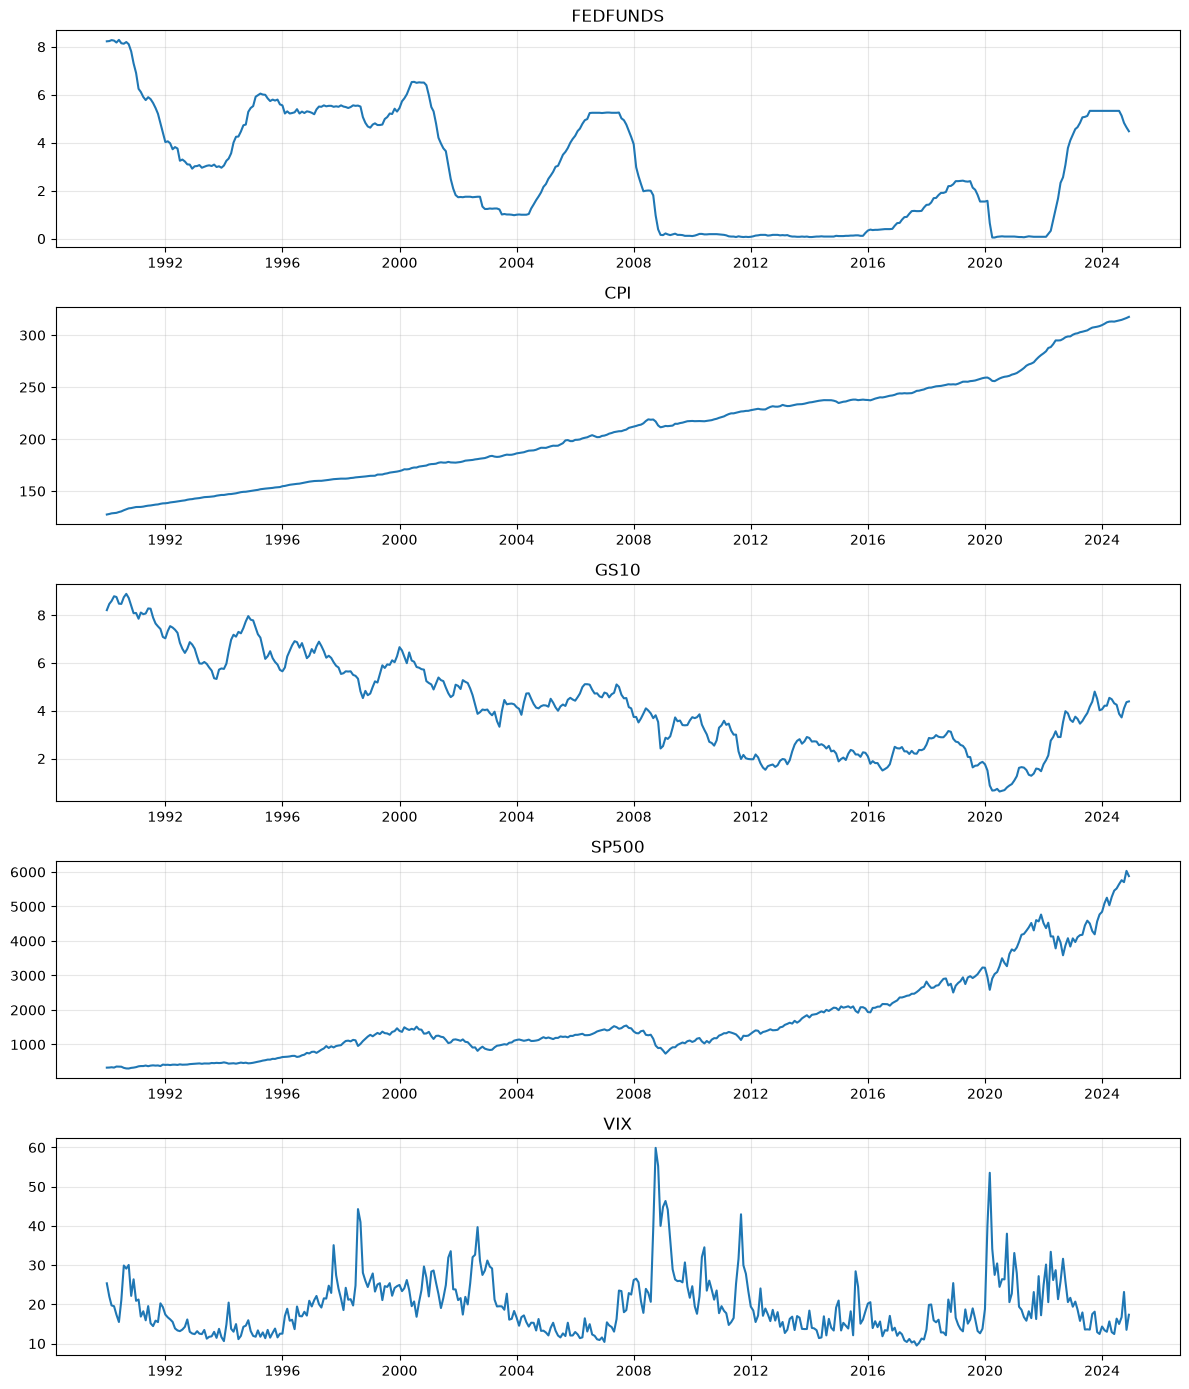

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("outputs/figures", exist_ok=True)
# Make sure the figures output folder exists before trying to save to it

files = {
    "FEDFUNDS": ("data/raw/fred_fedfunds.csv", 0),
    "CPI":      ("data/raw/fred_cpi.csv",      0),
    "GS10":     ("data/raw/fred_gs10.csv",      0),
    "SP500":    ("data/raw/yf_sp500.csv",       2),
    "VIX":      ("data/raw/yf_vix.csv",         2),
}

fig, axes = plt.subplots(5, 1, figsize=(12, 14))
# Creates a figure with 5 subplots stacked vertically, one per series
# figsize=(12, 14) sets the width and height in inches

for ax, (name, (path, skiprows)) in zip(axes, files.items()):
    df = pd.read_csv(path, index_col=0, skiprows=skiprows)
    df.index = pd.to_datetime(df.index) 
    # index_col=0 makes the first column (the dates) the row index
    # parse_dates=True tells pandas to interpret that index as actual dates

    print(f"\n{name}")
    print(f"  Rows: {df.shape[0]}")
    print(f"  Date range: {df.index[0].date()} to {df.index[-1].date()}")
    print(f"  Missing values: {df.isnull().sum().values[0]}")
    print(f"  First value: {df.iloc[0,0]:.4f}, Last value: {df.iloc[-1,0]:.4f}")
    # This prints a quick summary so you can verify the data at a glance

    ax.plot(df.index, df.iloc[:, 0])
    ax.set_title(name, fontsize=12)
    ax.grid(True, alpha=0.3)
    # Plots the series with light grid lines

plt.tight_layout()
# Adjusts spacing between subplots so labels don't overlap

plt.savefig("outputs/figures/01_raw_data.png", dpi=150)
# Saves the figure so it becomes part of your repository
# dpi=150 gives a reasonably high-resolution image

plt.show()